In [9]:
from PIL import Image
import os

from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils import data
import torchvision.transforms.v2 as tfs
import torchvision.models as models

In [10]:
# !pip uninstall torch torchvision torchaudio -y
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [11]:
import torch
print(f"Версия PyTorch: {torch.__version__}")
print(f"CUDA доступна: {torch.cuda.is_available()}")

Версия PyTorch: 2.7.1+cu118
CUDA доступна: True


In [12]:
class DataSet(data.Dataset):
    def __init__(self, train=True, transforms=None):
        self.transforms = transforms
        self.train = train

        if train:
            listdir_cats = os.listdir('/kaggle/input/competitions/ninja-neural-nets-dogs-vs-cats/train/cats')
            listdir_dogs = os.listdir('/kaggle/input/competitions/ninja-neural-nets-dogs-vs-cats/train/dogs')
            cats_path = list(map(lambda x: [os.path.join(f'/kaggle/input/competitions/ninja-neural-nets-dogs-vs-cats/train/cats/{x}'), [1,0]], listdir_cats))
            dogs_path = list(map(lambda x: [os.path.join(f'/kaggle/input/competitions/ninja-neural-nets-dogs-vs-cats/train/dogs/{x}'), [0,1]], listdir_dogs))
            self.path = [*cats_path, *dogs_path]

            self.length = len(self.path)   
        
        if train == False:
            test_path = os.listdir('/kaggle/input/competitions/ninja-neural-nets-dogs-vs-cats/test')
            self.path = list(map(lambda x: os.path.join(f'/kaggle/input/competitions/ninja-neural-nets-dogs-vs-cats/test/{x}'), test_path))
            self.length = len(self.path)

    def __getitem__(self, index):
        if self.train:
            img_path, target = self.path[index]
            img = Image.open(img_path).convert('RGB')
            img = self.transforms(img)
            return img, torch.tensor(target, dtype=torch.float32)
        
        else:
            img_path = self.path[index]
            img = Image.open(img_path).convert('RGB')
            img = self.transforms(img)
            return img
        
    def __len__(self):
        return self.length

In [13]:
tfs = tfs.Compose([
    tfs.Resize((224, 224)),
    tfs.ToImage(),
    tfs.ToDtype(dtype=torch.float32, scale=True)
])
train_val_data = DataSet(transforms=tfs, train=True)
d_train, d_val = data.random_split(train_val_data, [0.9, 0.1])

batch_size = 32
train_data = data.DataLoader(d_train, batch_size=batch_size, shuffle=True)
val_data = data.DataLoader(d_val, batch_size=32, shuffle=False)

test = DataSet(transforms=tfs, train=False)
test_data = data.DataLoader(test, batch_size=32, shuffle=False)

In [14]:
model = models.resnet50(weights = models.ResNet50_Weights.DEFAULT)

for params in model.parameters():
    params.requires_grad = False
    
for i, layer in enumerate(model.children()):
    if i>=7:
        for params in layer.parameters():
            params.requires_grad = True

in_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.5),
    nn.Linear(512, 2)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [15]:
old_params = []
new_params = []

for name, params in model.named_parameters():
    if params.requires_grad == True:
        if 'layer4' in name:
            old_params.append(params)
        else:
            new_params.append(params)

optimizer = torch.optim.RMSprop([
    {'params': old_params, 'lr':1e-5},
    {'params':new_params, 'lr':1e-3, 'weight_decay':1e-5}
])

epochs = 8
loss_func = nn.BCEWithLogitsLoss()

In [16]:
train_losses = []
val_losses = []

model.train()
for epoch in range(epochs):
    loss_mean = 0
    lm_count = 0

    train_tqdm = tqdm(train_data, leave=True)
    for x_train, y_train in train_tqdm:
        x_train = x_train.to(device)
        y_train = y_train.to(device)
        
        predict = model(x_train)
        loss = loss_func(predict, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        lm_count += 1
        loss_mean = 1/lm_count * loss.item() + (1 - 1/lm_count) * loss_mean
        train_tqdm.set_description(f"Epoch [{epoch+1}/{epochs}], loss_mean={loss_mean:.3f}")

    train_losses.append(loss_mean)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_val, y_val in val_data:
            x_val, y_val = x_val.to(device), y_val.to(device)
            outputs = model(x_val)
            loss = loss_func(outputs, y_val)
            val_loss += loss.item() * x_val.size(0)  # суммируем loss по батчам с учётом размера
    val_loss /= len(val_data.dataset)  # средний loss на один образец
    val_losses.append(val_loss)

    model_weights_path = f'model_weights{epoch}.pth'
    torch.save(model.state_dict(), model_weights_path)

model_weights_path = 'model_weights.pth'
torch.save(model.state_dict(), model_weights_path)
print(f"Веса модели успешно сохранены в {model_weights_path}")

Epoch [8/8], loss_mean=0.003: 100%|██████████| 282/282 [00:51<00:00,  5.42it/s]


Веса модели успешно сохранены в model_weights.pth


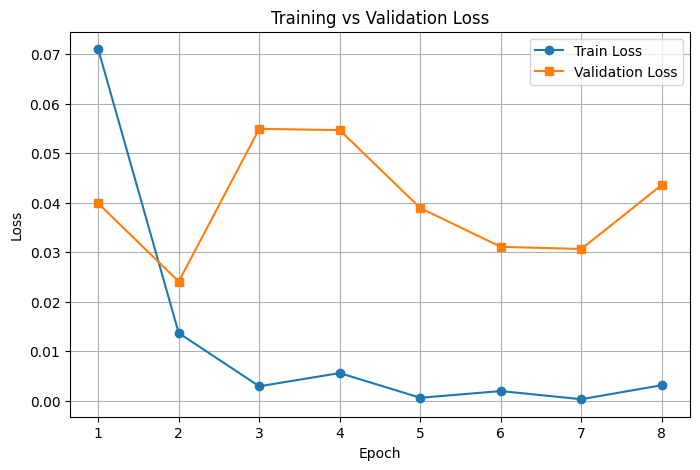

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
def calc_accuracy(model, val_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)          # one-hot: [1,0] или [0,1]
            y_true = torch.argmax(y, dim=1)
            pred = model(x)
            y_pred = torch.argmax(pred, dim=1)
            correct += (y_pred == y_true).sum().item()
            total += y.size(0)
    return correct / total

# Использование (пример):
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
acc = calc_accuracy(model, val_data, device)
print(f"Validation accuracy: {acc:.4f}")

Validation accuracy: 0.9890


In [19]:
weights_path = 'model_weights.pth' # Укажите путь к скачанному файлу
model.load_state_dict(torch.load(weights_path, map_location=torch.device('cuda')))

<All keys matched successfully>

In [20]:
import pandas as pd

model.eval()
all_preds = []
for x_test in test_data:
    x_test = x_test.to(device)
    with torch.no_grad():
        predict = model(x_test).squeeze(0)
        p = torch.argmax(predict, dim=1)
        p = p.tolist()
        all_preds.extend(p)

test_filenames = os.listdir('/kaggle/input/competitions/ninja-neural-nets-dogs-vs-cats/test')
submission = pd.DataFrame({
    'id': [fname for fname in test_filenames],  # берём имя без .jpg
    'label': all_preds
})
submission.to_csv('sample_submission.csv', index=False)